In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score


In [21]:
df = pd.read_csv('/home/nursss/Загрузки/plant_health_data.csv')

# Remove non-informative columns
df = df.drop(columns=["Plant_ID", "Timestamp"], errors="ignore")

# Encode target
le = LabelEncoder()
df["Target"] = le.fit_transform(df["Plant_Health_Status"])

X = df.drop(columns=["Plant_Health_Status", "Target"])
y = df["Target"]

# Train-test split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (960, 11)
Test shape: (240, 11)


Baseline Model — Logistic Regression

In [23]:
baseline = LogisticRegression(max_iter=3000)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))

Baseline Accuracy: 0.7166666666666667


/home/nursss/PycharmProjects/Agricultural_ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest

In [24]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


Cross-Validation on full dataset

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")
print("CV Mean:", cv_scores.mean())
print("CV Std:", cv_scores.std())

CV Mean: 0.9966666666666667
CV Std: 0.003118047822311607


Feature Importance

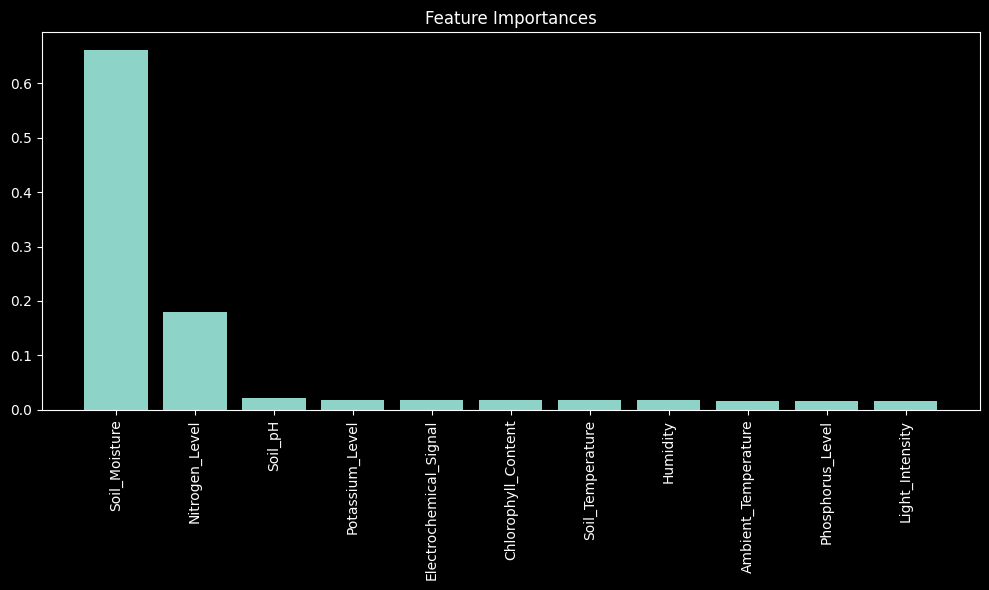

In [26]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

Analysis with single feature (Soil_Moisture)

In [27]:
X_single = X[["Soil_Moisture"]]
scores_single = cross_val_score(rf, X_single, y, cv=cv)
print("Only Soil_Moisture CV:", scores_single.mean())

Only Soil_Moisture CV: 0.7933333333333333


Analysis without Soil_Moisture

In [28]:
X_no_moisture = X.drop(columns=["Soil_Moisture"])
scores_no = cross_val_score(rf, X_no_moisture, y, cv=cv)
print("Without Soil_Moisture CV:", scores_no.mean())

Without Soil_Moisture CV: 0.45249999999999996


Final Model Training on full dataset

In [30]:
final_model = RandomForestClassifier(n_estimators=500, max_depth=200, random_state=42)
final_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",200
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

Save final model

In [44]:
joblib.dump(final_model, "plant_health_model.pkl")
print("Model saved as plant_health_model.pkl")

Model saved as plant_health_model.pkl


In [33]:
y_pred = final_model.predict(X_test)

Метрики

In [34]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 1.0


In [38]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 60   0   0]
 [  0 100   0]
 [  0   0  80]]


In [39]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

                 precision    recall  f1-score   support

        Healthy       1.00      1.00      1.00        60
    High Stress       1.00      1.00      1.00       100
Moderate Stress       1.00      1.00      1.00        80

       accuracy                           1.00       240
      macro avg       1.00      1.00      1.00       240
   weighted avg       1.00      1.00      1.00       240



In [40]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
y_pred_prob = final_model.predict_proba(X_test)
auc = roc_auc_score(y_test_bin, y_pred_prob, average="macro")
print("ROC-AUC:", auc)

ROC-AUC: 1.0


In [41]:
f1 = f1_score(y_test, y_pred, average="weighted")
print("F1-score:", f1)

F1-score: 1.0


In [42]:
y_pred

array([0, 2, 0, 0, 0, 1, 0, 2, 1, 0, 2, 0, 1, 1, 0, 1, 2, 0, 1, 1, 2, 0,
       0, 1, 1, 0, 2, 1, 0, 0, 0, 2, 1, 2, 2, 2, 2, 1, 2, 0, 2, 2, 2, 1,
       2, 2, 2, 2, 1, 1, 0, 0, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 0, 1, 1,
       0, 1, 2, 2, 1, 1, 0, 1, 1, 1, 2, 1, 1, 1, 2, 0, 0, 1, 1, 0, 1, 2,
       1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 0, 1, 1, 2, 2, 2, 2, 1, 0, 0, 0, 1,
       1, 1, 2, 1, 0, 2, 0, 1, 2, 2, 1, 2, 1, 0, 1, 1, 0, 1, 1, 2, 2, 2,
       1, 2, 1, 0, 0, 2, 0, 2, 2, 0, 0, 0, 1, 2, 2, 0, 1, 2, 1, 1, 1, 1,
       1, 2, 1, 0, 2, 1, 2, 2, 0, 0, 2, 2, 0, 1, 2, 1, 2, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 1, 1, 1, 2,
       0, 1, 0, 2, 0, 1, 0, 1, 1, 0, 2, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 1,
       2, 2, 0, 2, 1, 1, 1, 1, 0, 1, 2, 1, 2, 1, 0, 0, 1, 2, 1, 0])

In [45]:
def evaluate_model(model, X_input, y_true=None, label_encoder=None):
    """
    model: обученная классификационная модель
    X_input: pd.DataFrame или np.array с признаками для предсказания
    y_true: реальные метки (опционально, для оценки)
    label_encoder: LabelEncoder, если нужно показать имена классов в отчете
    """
    # Предсказание классов
    y_pred = model.predict(X_input)

    results = {"predictions": y_pred}

    if y_true is not None:
        # Accuracy
        results["accuracy"] = accuracy_score(y_true, y_pred)
        # F1-score
        results["f1_weighted"] = f1_score(y_true, y_pred, average="weighted")
        # Confusion matrix
        results["confusion_matrix"] = confusion_matrix(y_true, y_pred)
        # Classification report
        if label_encoder is not None:
            target_names = label_encoder.classes_
            results["classification_report"] = classification_report(y_true, y_pred, target_names=target_names)
        else:
            results["classification_report"] = classification_report(y_true, y_pred)

    return results

In [46]:
results = evaluate_model(final_model, X_test, y_test, label_encoder=le)

print("Accuracy:", results["accuracy"])
print("F1-weighted:", results["f1_weighted"])
print("Confusion Matrix:\n", results["confusion_matrix"])
print("Classification Report:\n", results["classification_report"])

Accuracy: 1.0
F1-weighted: 1.0
Confusion Matrix:
 [[ 60   0   0]
 [  0 100   0]
 [  0   0  80]]
Classification Report:
                  precision    recall  f1-score   support

        Healthy       1.00      1.00      1.00        60
    High Stress       1.00      1.00      1.00       100
Moderate Stress       1.00      1.00      1.00        80

       accuracy                           1.00       240
      macro avg       1.00      1.00      1.00       240
   weighted avg       1.00      1.00      1.00       240



In [53]:
def predict_plant_health_safe(model, X_input, label_encoder=None):
    """
    Безопасное предсказание для одного объекта или набора объектов,
    автоматически подставляет недостающие признаки моковыми значениями (0.5, 10.0, 25.0 и т.д.).
    """
    import pandas as pd
    import numpy as np

    expected_features = model.feature_names_in_

    # Если словарь / Series, превращаем в DataFrame
    if isinstance(X_input, dict):
        X_input = pd.DataFrame([X_input])
    elif isinstance(X_input, pd.Series):
        X_input = pd.DataFrame([X_input])
    elif isinstance(X_input, np.ndarray) and X_input.ndim == 1:
        X_input = pd.DataFrame([X_input], columns=expected_features)

    # Добавляем недостающие признаки с моковыми значениями
    for f in expected_features:
        if f not in X_input.columns:
            if "Moisture" in f or "pH" in f or "Signal" in f:
                X_input[f] = 0.5
            elif "Temperature" in f:
                X_input[f] = 25.0
            elif "Level" in f or "Content" in f:
                X_input[f] = 10.0
            else:
                X_input[f] = 0.0

    # Удаляем лишние признаки
    X_input = X_input[expected_features]

    # Предсказание
    y_pred = model.predict(X_input)

    if label_encoder is not None:
        y_pred = label_encoder.inverse_transform(y_pred)

    # Если один объект, возвращаем строку
    if len(y_pred) == 1:
        return y_pred[0]
    return y_pred

In [54]:
single_plant_mock = {
    "Soil_Moisture": 0.45,
    "Ambient_Temperature": 24.0,
    "Soil_Temperature": 25.0,
    "Humidity": 60.0,
    "Light_Intensity": 300,
    "Soil_pH": 6,
    "Nitrogen_Level": 15.0,
    "Phosphorus_Level": 8.0,
    "Potassium_Level": 20,
    "Chlorophyll_Content": 35.0,
    "Electrochemical_Signal": 0.12,

}

predicted_class = predict_plant_health_safe(final_model, single_plant_mock, label_encoder=le)
print("Predicted class (mock):", predicted_class)

predicted_class = predict_plant_health_safe(final_model, single_plant_mock, label_encoder=le)
print("Predicted class (original):", predicted_class)

Predicted class (mock): High Stress
Predicted class (original): High Stress
